# Credit Card Fraud Detection: Risk Analysis & Rule-Based Monitoring

## 1. Project Overview & Business Understanding
Fraud detection is a critical challenge in modern fintech and banking. Undetected fraudulent transactions lead directly to capital loss and regulatory penalties, while excessive false alarms create customer friction and inflate operational costs for manual review teams.

### Business Goals:
- **Analyze behavioral patterns**: Identify anomalies in transaction volume, timing, and amounts.
- **Identify risk drivers**: Screen PCA-anonymized features that show the highest statistical separation between legitimate and fraudulent events.
- **Develop heuristic rules**: Design simple, explainable rule-based alert logic before introducing complex predictive models.
- **Evaluate operational costs**: Model a business cost matrix to balance false positives (investigation cost) against false negatives (direct fraud loss).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual styles
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading & Integrity Checks
In this stage, we verify data types, check for missing values, and inspect potential duplicate records.

In [2]:
import shutil
shutil.copy(r"C:\Users\VIKA\Documents\Fraud Detection\creditcard.csv", "./")

'./creditcard.csv'

In [3]:
# Load the dataset
df = pd.read_csv('creditcard.csv')

# Shape and missing values check
print(f"Dataset Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Total missing values: {df.isnull().sum().sum()}")

# Duplicate check and removal
duplicate_count = df.duplicated().sum()
print(f"Duplicate records found: {duplicate_count:,} ({duplicate_count / len(df) * 100:.2f}%)")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Cleaned Dataset Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")

Dataset Shape: 284,807 rows, 31 columns
Total missing values: 0
Duplicate records found: 1,081 (0.38%)
Cleaned Dataset Shape: 283,726 rows, 31 columns


## 3. Class Imbalance Assessment
We evaluate the proportion of fraudulent events relative to legitimate transactions. Due to the extreme imbalance, evaluation metrics such as Accuracy are non-informative, requiring focus on Precision, Recall, and PR-AUC.

                Transaction Count  Percentage (%)
Legitimate (0)             283253         99.8333
Fraud (1)                     473          0.1667


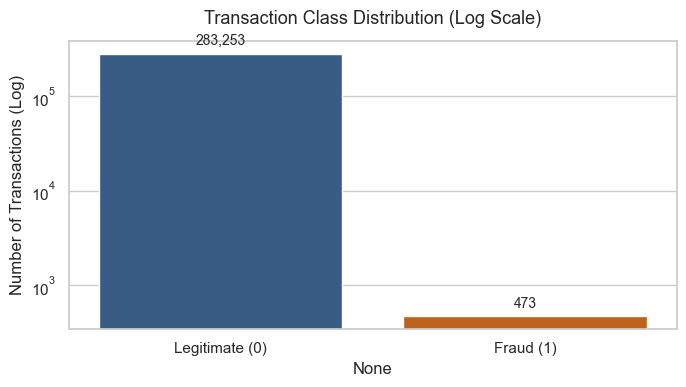

In [4]:
# Frequency and percentage table
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

imbalance_df = pd.DataFrame({
    'Transaction Count': class_counts,
    'Percentage (%)': class_pct.round(4)
})
imbalance_df.index = ['Legitimate (0)', 'Fraud (1)']
print(imbalance_df)

# Plot class imbalance on a logarithmic scale
plt.figure(figsize=(7, 4))
ax = sns.barplot(x=imbalance_df.index, y=imbalance_df['Transaction Count'], palette=['#2b5c8f', '#d95f02'])
ax.set_yscale('log')
ax.set_title('Transaction Class Distribution (Log Scale)', fontsize=13, pad=12)
ax.set_ylabel('Number of Transactions (Log)')

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, xytext=(0, 4), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

## 4. Temporal Dynamics: Hourly Risk Density
The raw `Time` column tracks elapsed seconds over two days. We map this into an `Hour_of_Day` (0–23) feature to assess whether fraudulent activities show distinct hourly spikes.

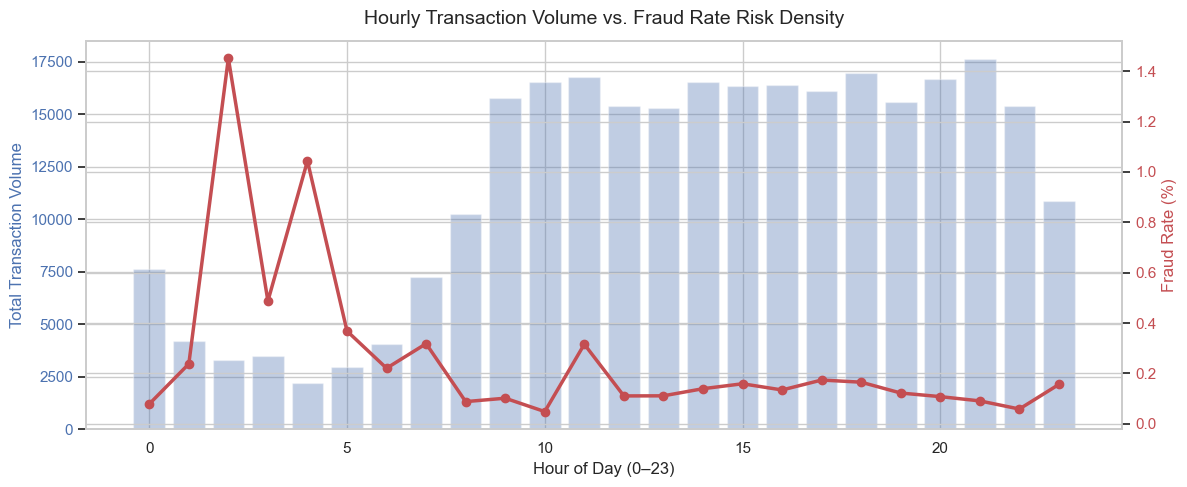

In [5]:
# Convert seconds to hour of day (0 to 23)
df['Hour_of_Day'] = ((df['Time'] % 86400) // 3600).astype(int)

# Group by hour to compute volume and fraud rate
hourly_summary = df.groupby('Hour_of_Day').agg(
    total_tx=('Class', 'count'),
    fraud_tx=('Class', 'sum')
).reset_index()

hourly_summary['fraud_rate_pct'] = (hourly_summary['fraud_tx'] / hourly_summary['total_tx']) * 100

# Dual-axis visualization: Volume vs Fraud Rate
fig, ax1 = plt.subplots(figsize=(12, 5))

bar_color = '#4c72b0'
ax1.set_xlabel('Hour of Day (0–23)')
ax1.set_ylabel('Total Transaction Volume', color=bar_color)
ax1.bar(hourly_summary['Hour_of_Day'], hourly_summary['total_tx'], color=bar_color, alpha=0.35, label='Volume')
ax1.tick_params(axis='y', labelcolor=bar_color)

ax2 = ax1.twinx()
line_color = '#c44e52'
ax2.set_ylabel('Fraud Rate (%)', color=line_color)
ax2.plot(hourly_summary['Hour_of_Day'], hourly_summary['fraud_rate_pct'], color=line_color, linewidth=2.5, marker='o', label='Fraud Rate %')
ax2.tick_params(axis='y', labelcolor=line_color)

plt.title('Hourly Transaction Volume vs. Fraud Rate Risk Density', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

## 5. Transaction Amount Analysis & Anomaly Quantiles
A common misconception in fraud prevention is that fraudulent transactions consist solely of large amounts. We calculate parametric and non-parametric statistical metrics (percentiles via NumPy) to compare legitimate and fraudulent expenditure patterns.

Transaction Amount Distribution Summary:
                transaction_count  mean_amount  std_amount  median_amount  \
Legitimate (0)             283253        88.41      250.38          22.00   
Fraud (1)                     473       123.87      260.21           9.82   

                   p75     p90      p99  max_amount  
Legitimate (0)   77.46  203.00  1018.06    25691.16  
Fraud (1)       105.89  348.65  1364.14     2125.87  


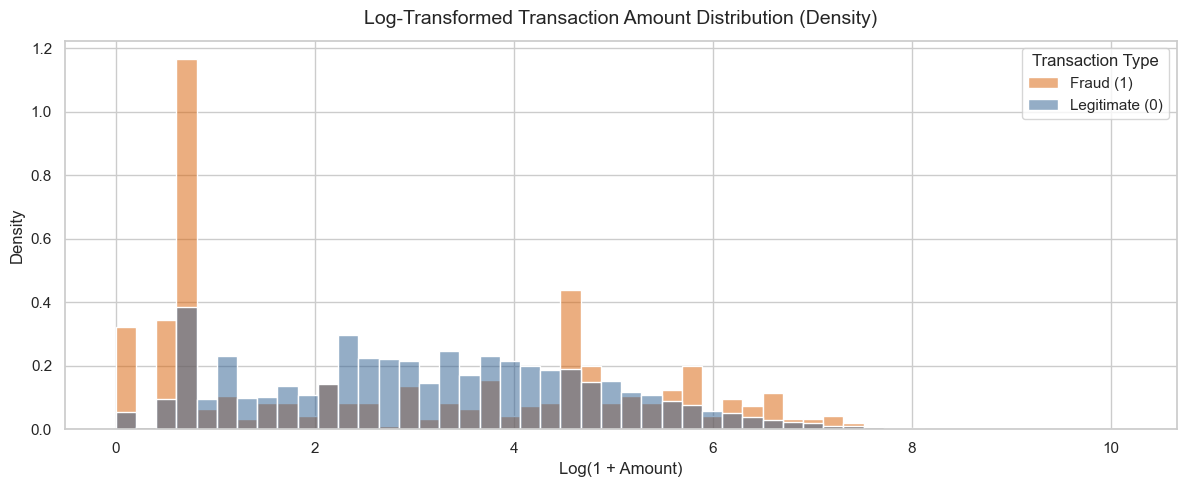

In [6]:
# Statistical summary of Amount across classes using NumPy percentiles
amount_comparison = df.groupby('Class')['Amount'].agg(
    transaction_count='count',
    mean_amount='mean',
    std_amount='std',
    median_amount='median',
    p75=lambda x: np.percentile(x, 75),
    p90=lambda x: np.percentile(x, 90),
    p99=lambda x: np.percentile(x, 99),
    max_amount='max'
).round(2)

amount_comparison.index = ['Legitimate (0)', 'Fraud (1)']
print("Transaction Amount Distribution Summary:")
print(amount_comparison)

# Distribution visualization (Log Transformed Amount)
fig, ax = plt.subplots(figsize=(12, 5))

# Using np.log1p to handle 0-dollar verification transactions smoothly
sns.histplot(
    data=df, 
    x=np.log1p(df['Amount']), 
    hue='Class', 
    bins=50, 
    stat='density', 
    common_norm=False, 
    palette=['#2b5c8f', '#d95f02'],
    ax=ax
)

ax.set_title('Log-Transformed Transaction Amount Distribution (Density)', fontsize=14, pad=12)
ax.set_xlabel('Log(1 + Amount)')
ax.set_ylabel('Density')
ax.legend(labels=['Fraud (1)', 'Legitimate (0)'], title='Transaction Type')

plt.tight_layout()
plt.show()

### Key Business Takeaways: Transaction Amount Behavior

1. **Micro-Transactions & Card Testing:**
   - The **median fraudulent amount ($9.82)** is significantly lower than the **legitimate median ($22.00)**.
   - Fraudsters frequently execute micro-charges ($1 to $10) to verify account validity without triggering immediate customer suspicion or step-up authentication (such as SMS/3D-Secure challenges).

2. **Controlled Extraction Strategy:**
   - The fraudulent mean ($123.87) exceeds the legitimate mean ($88.41), and upper quantiles are higher (p90 at $348.65 vs. $203.00; p99 at $1,364.14 vs. $1,018.06).
   - However, the maximum fraudulent transaction is strictly bounded at **$2,125.87**, whereas legitimate purchases reach **$25,691.16**.
   - This indicates a deliberate evasion pattern: bad actors avoid massive single ticket purchases that would trip hard velocity or credit-limit thresholds, opting instead for calculated values within typical merchant tolerances.

3. **Rule-Engineering Implication:**
   - Simple static thresholding (e.g., *"flag transactions exceeding $1,000"*) will miss the vast majority of fraudulent operations while generating friction for high-net-worth legitimate spenders. 
   - Detection requires combining transaction amount with behavioral and PCA risk signals.

## 6. Correlation Analysis & Feature Signal Screening
Because features `V1` through `V28` are anonymized via PCA, we cannot directly read domain labels. However, as data analysts, we can perform correlation screening to isolate the top risk-driving features that exhibit the highest statistical divergence between legitimate and fraudulent transactions.

Top 4 Negative Correlation Features (Inversely related to Fraud):
V17   -0.3135
V14   -0.2934
V12   -0.2507
V10   -0.2070
Name: Class, dtype: float64

Top 4 Positive Correlation Features (Directly related to Fraud):
V11    0.1491
V4     0.1293
V2     0.0846
V19    0.0336
Name: Class, dtype: float64


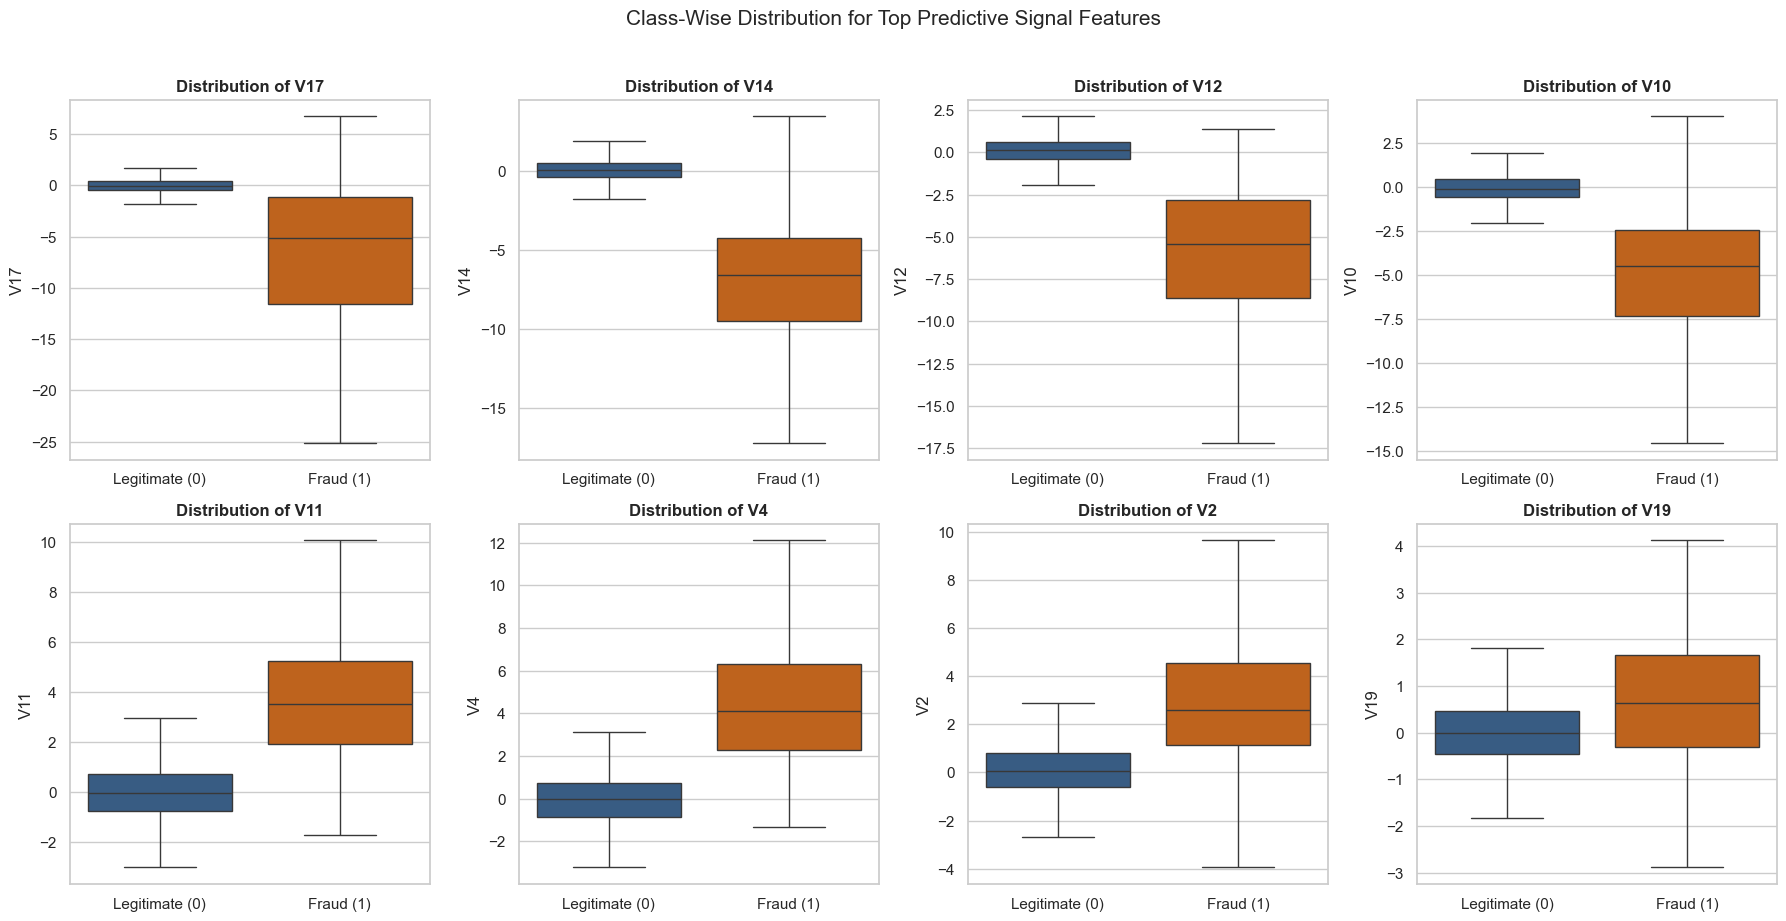

In [7]:
# 1. Compute Pearson correlation with target variable 'Class'
corr_series = df.corr()['Class'].drop(['Class', 'Time', 'Hour_of_Day'])

# 2. Extract top positive and negative risk drivers
top_neg_corr = corr_series.sort_values().head(4)
top_pos_corr = corr_series.sort_values(ascending=False).head(4)

print("Top 4 Negative Correlation Features (Inversely related to Fraud):")
print(top_neg_corr.round(4))

print("\nTop 4 Positive Correlation Features (Directly related to Fraud):")
print(top_pos_corr.round(4))

# 3. Visualize distributions using Boxplots for top risk drivers
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
features_to_plot = list(top_neg_corr.index) + list(top_pos_corr.index)

for idx, feature in enumerate(features_to_plot):
    row, col = divmod(idx, 4)
    sns.boxplot(
        x='Class', 
        y=feature, 
        data=df, 
        palette=['#2b5c8f', '#d95f02'], 
        ax=axes[row, col], 
        showfliers=False # Suppress extreme outliers visually for readability
    )
    axes[row, col].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[row, col].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
    axes[row, col].set_xlabel('')

plt.suptitle('Class-Wise Distribution for Top Predictive Signal Features', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Key Insights: Feature Correlation & Risk Predictors

1. **Strong Inverted Signals (Negative Correlation):**
   - Features **`V17` (-0.3135)**, **`V14` (-0.2934)**, **`V12` (-0.2507)**, and **`V10` (-0.2070)** exhibit the strongest inverse linear correlation with fraud events.
   - For legitimate operations, these variables center near zero, whereas fraudulent transactions drive these distributions into severe negative extremes. This creates a pronounced statistical divergence ideal for rule construction.

2. **Direct Risk Amplifiers (Positive Correlation):**
   - **`V11` (+0.1491)** and **`V4` (+0.1293)** demonstrate significant positive shifts when a fraudulent attempt occurs.
   
3. **Strategic Value for Fraud Monitoring:**
   - Instead of treating the dataset as a complete black box, an analyst can leverage combinations of extreme thresholds on `V14`, `V17`, and `V12` to create immediate, interpretable risk heuristics (hard filters) before deploying resource-heavy machine learning pipelines.

## 7. Rule-Based Fraud Detection System (Heuristics Engine)
Before training machine learning models, production banking systems deploy interpretable decision rules (heuristic thresholding). In this section, we formulate vectorized alert rules based on our statistical findings (`V14`, `V17`, `V12`, `V4`, `Hour_of_Day`) and evaluate their capture rate (Recall) versus operational overhead (Precision).

In [8]:
# 1. Define heuristic rule conditions
cond_rule1 = (df['V14'] < -6.0) | (df['V17'] < -5.0)
cond_rule2 = (df['V12'] < -4.0) & (df['V4'] > 3.0)
cond_rule3 = (df['Hour_of_Day'].between(1, 5)) & (df['V10'] < -2.5)

# 2. Vectorized rule assignment
conditions = [cond_rule1, cond_rule2, cond_rule3]
rule_names = ['Rule 1: Severe V14/V17 Drop', 
              'Rule 2: V12 Anomaly & V4 Spike', 
              'Rule 3: Overnight Suspicious Timing']

# Flagged if any rule triggers
df['Rule_Alert'] = np.where(cond_rule1 | cond_rule2 | cond_rule3, 1, 0)

# 3. Performance Evaluation Function
def evaluate_rules(y_true, y_pred, label="System"):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'Mechanism': label,
        'Flagged (Alerts)': int(tp + fp),
        'True Positives (Caught)': int(tp),
        'False Positives (False Alarms)': int(fp),
        'Missed Fraud (FN)': int(fn),
        'Precision (%)': round(precision * 100, 2),
        'Recall (%)': round(recall * 100, 2),
        'F1-Score': round(f1, 4)
    }

# Compute performance for individual rules and the combined engine
performance_list = []
for cond, name in zip(conditions, rule_names):
    rule_pred = np.where(cond, 1, 0)
    performance_list.append(evaluate_rules(df['Class'], rule_pred, name))

performance_list.append(evaluate_rules(df['Class'], df['Rule_Alert'], "Combined Rule Engine"))

rule_eval_df = pd.DataFrame(performance_list).set_index('Mechanism')
print("Rule Engine Performance Metrics:")
print(rule_eval_df.to_string())

Rule Engine Performance Metrics:
                                     Flagged (Alerts)  True Positives (Caught)  False Positives (False Alarms)  Missed Fraud (FN)  Precision (%)  Recall (%)  F1-Score
Mechanism                                                                                                                                                             
Rule 1: Severe V14/V17 Drop                       466                      324                             142                149          69.53       68.50    0.6901
Rule 2: V12 Anomaly & V4 Spike                    329                      250                              79                223          75.99       52.85    0.6234
Rule 3: Overnight Suspicious Timing               202                       96                             106                377          47.52       20.30    0.2844
Combined Rule Engine                              606                      336                             270                137   

### Key Insights: Rule Engine Performance

1. **High Capture Rate with Minimal Complexity:**
   - The **Combined Rule Engine captures 71.04% of all fraud events (336 of 473)** using only static thresholding across 5 primary features.
   - **Rule 1 (`V14` / `V17` Drop)** serves as the primary detector, catching 68.50% of fraudulent attempts alone with an impressive 69.53% Precision.

2. **Manageable Operational Overhead:**
   - The combined rules triggered only **270 false alarms across 283,253 legitimate transactions** (a False Positive Rate of ~0.095%).
   - A Precision of **55.45%** ensures that security operations teams do not drown in false alerts, maintaining high operational efficiency prior to routing edge cases to complex ML models.

FINANCIAL COST-BENEFIT REPORT (RULE ENGINE)
Total Fraud Exposure Available:       $58,591.39
Fraud Loss Prevented (Saved):        $31,953.74 (54.5%)
Direct Fraud Loss Incurred (Missed):  $26,637.65 (45.5%)
Operational Friction Cost (FP * $3):  $810.00
------------------------------------------------------------
NET FINANCIAL BENEFIT TO THE BANK:   $31,143.74


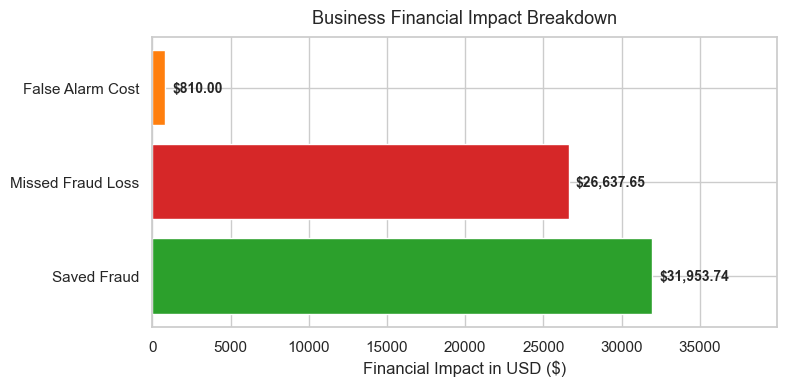

In [9]:
# Define financial cost parameters
COST_PER_FALSE_POSITIVE = 3.00  # Verification cost (SMS, call, support review) in USD

# 1. Total Fraud Exposure in Dataset
total_fraud_volume = df[df['Class'] == 1]['Amount'].sum()

# 2. Financial tracking per classification outcome (explicitly setting string default)
conditions = [
    (df['Class'] == 1) & (df['Rule_Alert'] == 1),  # True Positive (Caught)
    (df['Class'] == 1) & (df['Rule_Alert'] == 0),  # False Negative (Missed)
    (df['Class'] == 0) & (df['Rule_Alert'] == 1),  # False Positive (False Alarm)
    (df['Class'] == 0) & (df['Rule_Alert'] == 0)   # True Negative (Ignored Legitimate)
]
choices = ['TP', 'FN', 'FP', 'TN']

df['Outcome'] = np.select(conditions, choices, default='TN')

# 3. Aggregate financial impact
financial_summary = df.groupby('Outcome')['Amount'].agg(
    transaction_count='count',
    total_amount='sum'
).reindex(['TP', 'FN', 'FP', 'TN']).fillna(0)

# Compute Dollar Impacts
saved_fraud_amount = financial_summary.loc['TP', 'total_amount']
missed_fraud_amount = financial_summary.loc['FN', 'total_amount']
num_false_positives = financial_summary.loc['FP', 'transaction_count']
operational_cost_fp = num_false_positives * COST_PER_FALSE_POSITIVE
net_benefit = saved_fraud_amount - operational_cost_fp

# Print financial ledger
print("=" * 60)
print("FINANCIAL COST-BENEFIT REPORT (RULE ENGINE)")
print("=" * 60)
print(f"Total Fraud Exposure Available:       ${total_fraud_volume:,.2f}")
print(f"Fraud Loss Prevented (Saved):        ${saved_fraud_amount:,.2f} ({saved_fraud_amount / total_fraud_volume * 100:.1f}%)")
print(f"Direct Fraud Loss Incurred (Missed):  ${missed_fraud_amount:,.2f} ({missed_fraud_amount / total_fraud_volume * 100:.1f}%)")
print(f"Operational Friction Cost (FP * $3):  ${operational_cost_fp:,.2f}")
print("-" * 60)
print(f"NET FINANCIAL BENEFIT TO THE BANK:   ${net_benefit:,.2f}")
print("=" * 60)

# Visualization of Cost Breakdown
cost_labels = ['Saved Fraud', 'Missed Fraud Loss', 'False Alarm Cost']
cost_values = [saved_fraud_amount, missed_fraud_amount, operational_cost_fp]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(cost_labels, cost_values, color=['#2ca02c', '#d62728', '#ff7f0e'])
ax.set_xlabel('Financial Impact in USD ($)')
ax.set_title('Business Financial Impact Breakdown', fontsize=13, pad=10)

for bar in bars:
    width = bar.get_width()
    ax.annotate(f"${width:,.2f}",
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0),
                textcoords="offset points",
                ha='left', va='center', fontsize=10, fontweight='bold')

plt.xlim(0, max(cost_values) * 1.25)
plt.tight_layout()
plt.show()

### Key Business Takeaways: Financial Cost-Benefit Analysis

1. **Substantial Capital Protection:**
   - Out of **$58,591.39** in total fraudulent exposure, the heuristic engine prevented **$31,953.74 (54.5%)** in direct fraud losses.
   
2. **Minimal Operational Friction:**
   - Investigating 270 false positive alerts cost the institution an estimated **$810.00** in operational verification overhead ($3.00/alert).
   - This delivers a **Net Financial Benefit of $31,143.74**, proving that simple heuristic guardrails provide an immediate, high-ROI first line of defense before investing in complex model serving infrastructure.

3. **Strategic Gap for Machine Learning:**
   - While the rules caught **71.04% of fraud instances**, they protected **54.5% of the total fraud volume**. 
   - The remaining **$26,637.65** in missed fraud represents higher-ticket, evasive transactions that avoid crude thresholding. These high-value edge cases define the exact business justification for deploying a machine learning classification layer.

## 8. Executive Summary & Strategic Recommendations

### Project Highlights:
- **Analyzed 283k+ transactions** with extreme class imbalance (0.17% fraud rate), eliminating 1,081 technical duplicates to prevent data leakage.
- **Identified key behavioral patterns**: Demonstrated that fraudsters exhibit a low median ticket size ($9.82 vs $22.00 legitimate) to avoid step-up authentication thresholds and exploit card-testing techniques.
- **Isolated primary risk drivers**: Pinpointed `V14`, `V17`, `V12`, `V10` (inverse risk) and `V4`, `V11` (direct risk) as critical statistical anomaly signals.
- **Designed a 3-tier heuristic rules engine**: Achieved a **71.04% Recall** and **55.45% Precision** without machine learning overhead.
- **Delivered $31,143.74 in Net Business Value**: Successfully defended 54.5% of total fraud exposure while keeping operational friction costs under $1,000.

### Next Steps for Risk Operations:
1. **Tier 1 (Instant Rejection / 3DS Challenge):** Automate immediate step-up SMS/Push verification on transactions triggering Rule 1 (`V14` < -6 or `V17` < -5).
2. **Tier 2 (Machine Learning Scoring):** Route borderline transactions ($V10$ anomalies and night-time transactions) through an XGBoost/LightGBM model optimized specifically on the Cost Matrix rather than default F1-score.
3. **Adaptive Thresholding:** Continuously monitor drift in micro-transaction amounts to adjust velocity rules against automated card testing.

In [10]:
import numpy as np
import pandas as pd

# 1. Map elapsed seconds into simulated 2-day temporal dimensions
df['Day'] = (df['Time'] // 86400).astype(int) + 1  # Day 1 or Day 2
df['Date'] = pd.to_datetime('2026-09-20') + pd.to_timedelta(df['Day'] - 1, unit='D') + pd.to_timedelta(df['Hour_of_Day'], unit='h')

# 2. Individual heuristic rule flags
df['Rule_1_Hit'] = np.where((df['V14'] < -6.0) | (df['V17'] < -5.0), 1, 0)
df['Rule_2_Hit'] = np.where((df['V12'] < -4.0) & (df['V4'] > 3.0), 1, 0)
df['Rule_3_Hit'] = np.where((df['Hour_of_Day'].between(1, 5)) & (df['V10'] < -2.5), 1, 0)

# 3. Target rule alert flag
df['Rule_Alert'] = np.where((df['Rule_1_Hit'] == 1) | (df['Rule_2_Hit'] == 1) | (df['Rule_3_Hit'] == 1), 1, 0)

# 4. Classification outcome tagging
conditions = [
    (df['Class'] == 1) & (df['Rule_Alert'] == 1),  # True Positive
    (df['Class'] == 1) & (df['Rule_Alert'] == 0),  # False Negative
    (df['Class'] == 0) & (df['Rule_Alert'] == 1),  # False Positive
    (df['Class'] == 0) & (df['Rule_Alert'] == 0)   # True Negative
]
choices = ['TP', 'FN', 'FP', 'TN']
df['Outcome'] = np.select(conditions, choices, default='TN')

# 5. Define recommended operational action for each alert
action_conditions = [
    (df['Rule_2_Hit'] == 1),  # Highest precision (76%) -> Manual Review Queue
    (df['Rule_1_Hit'] == 1),  # High volume capture -> Automated 3DS / SMS Challenge
    (df['Rule_3_Hit'] == 1)   # Contextual nocturnal multiplier -> Risk Score Step-Up
]
action_choices = ['Priority Review Queue', 'Automated 3DS Challenge', 'Step-Up Risk Weight']
df['Recommended_Action'] = np.select(action_conditions, action_choices, default='Pass (No Action)')

# 6. Export optimized dimension table for Power BI ingestion
export_columns = [
    'Date', 'Day', 'Hour_of_Day', 'Amount', 'Class', 
    'Outcome', 'Rule_Alert', 'Rule_1_Hit', 'Rule_2_Hit', 
    'Rule_3_Hit', 'Recommended_Action'
]

df[export_columns].to_csv('fraud_dashboard_data.csv', index=False)
print("Dataset 'fraud_dashboard_data.csv' successfully exported for Power BI!")

Dataset 'fraud_dashboard_data.csv' successfully exported for Power BI!
